In [44]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from typing import List, Any

import warnings
warnings.filterwarnings('ignore')

In [45]:
# options
pd.set_option('display.max_columns', None)

In [46]:
df = pd.read_csv('eda_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [47]:
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].astype(int)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 1
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6328, 19), (704, 19), (6328,), (704,))

In [48]:
numeric = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical = list(set(X_train.columns) - set(numeric))

X_train_num = X_train.loc[:, numeric]
X_test_num = X_test.loc[:, numeric]

X_train_cat = X_train.loc[:, categorical]
X_test_cat = X_test.loc[:, categorical]

ss = StandardScaler()
X_train_num = ss.fit_transform(X_train_num)
X_test_num = ss.transform(X_test_num)

X_train_scaled = np.hstack([X_train_num, X_train_cat])
X_test_scaled = np.hstack([X_test_num, X_test_cat])

X_train_scaled.shape, X_test_scaled.shape

((6328, 19), (704, 19))

In [49]:
numeric = ["tenure", "MonthlyCharges", "TotalCharges"]
numeric_full = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"] 
categorical = list(set(X_train.columns) - set(numeric_full))

len(numeric), len(categorical), len(X_train.columns)

(3, 15, 19)

In [50]:
ct_scaled = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric),
        ("categorical", OneHotEncoder(drop = 'first'), categorical),
        ("numerics", "passthrough", ["SeniorCitizen"])
    ]
)
X_train_tr_scaled = ct_scaled.fit_transform(X_train)
X_test_tr_scaled = ct_scaled.transform(X_test)

X_train_tr_scaled.shape, X_test_tr_scaled.shape

((6328, 23), (704, 23))

In [51]:
ct = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_full),
        ("categorical", OneHotEncoder(drop = 'first'), categorical)
    ]
)
X_train_tr = ct.fit_transform(X_train)
X_test_tr = ct.transform(X_test)

X_train_tr.shape, X_test_tr.shape

((6328, 23), (704, 23))

In [52]:
import tqdm
from utils import estimate_quality

import xgboost
import catboost
import sklearn.svm
import sklearn.tree
import sklearn.ensemble
import sklearn.neighbors
import sklearn.naive_bayes
import sklearn.linear_model
import sklearn.neural_network

models = [
    # neighbors
    sklearn.neighbors.KNeighborsClassifier(n_jobs = -1, n_neighbors = 50),
    sklearn.neighbors.RadiusNeighborsClassifier(n_jobs = -1, radius = 7),

    # naive_bayes
    sklearn.naive_bayes.BernoulliNB(),
    sklearn.naive_bayes.GaussianNB(),

    # linear_model
    sklearn.linear_model.LogisticRegression(),
    
    # svm
    sklearn.svm.SVC(probability = True),
    sklearn.svm.NuSVC(probability = True),
    
    # tree
    sklearn.tree.DecisionTreeClassifier(),
    sklearn.tree.ExtraTreeClassifier(),

    # ensemble
    sklearn.ensemble.BaggingClassifier(n_estimators = 100, random_state = 42, n_jobs = -1),
    sklearn.ensemble.AdaBoostClassifier(n_estimators = 500, algorithm = 'SAMME', random_state = 42),
    sklearn.ensemble.ExtraTreesClassifier(n_estimators = 500, random_state = 42, n_jobs = -1),
    sklearn.ensemble.RandomForestClassifier(n_estimators = 1000, random_state = 42, n_jobs = -1),
    sklearn.ensemble.GradientBoostingClassifier(n_estimators = 1000, random_state = 42),
    sklearn.ensemble.HistGradientBoostingClassifier(random_state = 42),

    # neural_network
    sklearn.neural_network.MLPClassifier(max_iter = 2000),
    
    # xgboost
    xgboost.XGBClassifier(n_jobs = -1, n_estimators = 50, max_depth = 4, device = 'gpu'),

    # catboost
    catboost.CatBoostClassifier(
        # iterations = 600,
        # depth = 4,
        random_seed = 42,
        loss_function = 'MultiClass',
        devices = '0-3',
        # task_type = 'GPU',
        verbose = False
    ),
]

# results = []
# for model in tqdm.tqdm(models):
#     model.fit(X_train_scaled, y_train)
#     metrics = estimate_quality(model.predict_proba(X_test_scaled), y_test)
#     results.append({ 'model': str(model), **metrics })
# pandas.DataFrame(results)

In [53]:
from sklearn.model_selection import GridSearchCV

params = [
    # sklearn.neighbors.KNeighborsClassifier
    {'n_neighbors': [10, 30, 50, 70], 'weights': ['uniform', 'distance']},
    
    # sklearn.neighbors.RadiusNeighborsClassifier
    {'radius': [3, 5, 7], 'weights': ['uniform', 'distance']},
    
    # sklearn.naive_bayes.BernoulliNB
    {'alpha': [0.1, 1.0, 10.0]},
    
    # sklearn.naive_bayes.GaussianNB
    {'var_smoothing': [1e-9, 1e-8, 1e-7]},
    
    # sklearn.linear_model.LogisticRegression
    {'C': [0.1, 1.0, 10.0], 'penalty': ['l1', 'l2', 'none'], 'class_weight': [None, 'balanced']}
    ,
    # sklearn.svm.SVC
    {'C': [0.1, 1.0, 10.0], 'kernel': ['linear', 'rbf']},
    
    # sklearn.svm.NuSVC
    {'nu': [0.3, 0.5, 0.7], 'kernel': ['linear', 'rbf']},
    
    # sklearn.tree.DecisionTreeClassifier
    {'max_depth': [None, 4, 8, 16], 'min_samples_split': [2, 10, 50], 'criterion': ['gini', 'entropy', 'log_loss']},
    
    # sklearn.tree.ExtraTreeClassifier
    {'max_depth': [None, 4, 8, 16], 'min_samples_split': [2, 10, 50], 'criterion': ['gini', 'entropy', 'log_loss']},
    
    # sklearn.ensemble.BaggingClassifier
    {'n_estimators': [10, 50, 100], 'max_samples': [0.5, 0.9, 1.0]},
    
    # sklearn.ensemble.AdaBoostClassifier
    {'n_estimators': [100, 300, 500], 'learning_rate': [0.5, 1.0, 10.0]},
    
    # sklearn.ensemble.ExtraTreesClassifier
    {'n_estimators': [100, 200, 500], 'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 10, 50], 'criterion': ['gini', 'entropy', 'log_loss']},
    
    # sklearn.ensemble.RandomForestClassifier
    {'n_estimators': [100, 300, 1000], 'max_depth': [None, 5, 10, 15], 'min_samples_split': [2, 10, 50], 'criterion': ['gini', 'entropy', 'log_loss']},
    
    # sklearn.ensemble.GradientBoostingClassifier
    {'n_estimators': [100, 500, 1000], 'learning_rate': [0.001, 0.05, 0.1], 'max_depth': [3, 5, 10], 'min_samples_split': [2, 10, 50],},
    
    # sklearn.ensemble.HistGradientBoostingClassifier
    {'max_iter': [100, 300], 'max_depth': [None, 5, 10, 15], 'learning_rate': [0.001, 0.05, 0.1]},
    
    # sklearn.neural_network.MLPClassifier
    {'hidden_layer_sizes': [(100,), (200,)], 'activation': ['identity', 'logistic', 'tanh', 'relu'], 'learning_rate_init': [0.001, 0.01, 0.05]},
    
    # xgboost.XGBClassifier
    {'n_estimators': [20, 50, 100], 'max_depth': [3, 4, 5, 8], 'learning_rate': [0.05, 0.1]},
    
    # catboost.CatBoostClassifier
    {'iterations': [100, 200, 400], 'depth': [3, 4, 5, 8], 'learning_rate': [0.01, 0.05, 0.1]},
]

scaled_models = [
    "KNeighborsClassifier",
    "RadiusNeighborsClassifier",
    "LogisticRegression",
    "SVC",
    "NuSVC",
    "GradientBoostingClassifier",
    "HistGradientBoostingClassifier",
    "MLPClassifier"
]

results = []
for model, param_grid in tqdm.tqdm(zip(models, params), total=len(models)):
    try:
        if type(model).__name__ == "CatBoostClassifier":
            # CatBoost не поддерживает n_jobs
            grid = GridSearchCV(model, param_grid, scoring='neg_log_loss', cv=3, refit=True)
        else:
            grid = GridSearchCV(model, param_grid, scoring='neg_log_loss', cv=3, n_jobs=-1, refit=True)
        if type(model).__name__ in scaled_models:
            grid.fit(X_train_tr_scaled, y_train)
            best_model = grid.best_estimator_
            proba = best_model.predict_proba(X_test_tr_scaled)
        else:
            grid.fit(X_train_tr, y_train)
            best_model = grid.best_estimator_
            proba = best_model.predict_proba(X_test_tr)
        
        metrics = estimate_quality(proba, y_test)
        results.append({ 'model': str(best_model), 'best_params': grid.best_params_, **metrics })
    except Exception as e:
        print({ 'model': str(model), 'best_params': None, 'error': str(e) })
        results.append({ 'model': str(model), 'best_params': None, 'error': str(e) })

pd.DataFrame(results)


100%|██████████| 18/18 [06:35<00:00, 22.00s/it]


,model,best_params,Accuracy,Precision,Recall,AUC-ROC,F1-score,True Positive,True Negative,False Positive,False Negative,True Negative Rate (Specificity),Negative Predictive Value,False Positive Rate,False Discovery Rate
0,"KNeighborsClassifier(n_jobs=-1, n_neighbors=70)","{'n_neighbors': 70, 'weights': 'uniform'}",0.796875,0.634146,0.556150,0.814618,0.592593,104,457,60,83,0.883946,0.846296,0.116054,0.365854
1,"RadiusNeighborsClassifier(n_jobs=-1, radius=3)","{'radius': 3, 'weights': 'uniform'}",0.788352,0.702128,0.352941,0.793285,0.469751,66,489,28,121,0.945841,0.801639,0.054159,0.297872
2,BernoulliNB(alpha=10.0),{'alpha': 10.0},0.764205,0.547511,0.647059,0.809990,0.593137,121,417,100,66,0.806576,0.863354,0.193424,0.452489
3,GaussianNB(var_smoothing=1e-07),{'var_smoothing': 1e-07},0.737216,0.503597,0.748663,0.814934,0.602151,140,379,138,47,0.733075,0.889671,0.266925,0.496403
4,LogisticRegression(),"{'C': 1.0, 'class_weight': None, 'penalty': 'l2'}",0.802557,0.655844,0.540107,0.822826,0.592375,101,464,53,86,0.897485,0.843636,0.102515,0.344156
5,"SVC(C=10.0, kernel='linear', probability=True)","{'C': 10.0, 'kernel': 'linear'}",0.798295,0.649007,0.524064,0.810455,0.579882,98,464,53,89,0.897485,0.839060,0.102515,0.350993
6,"NuSVC(kernel='linear', probability=True)","{'kernel': 'linear', 'nu': 0.5}",0.799716,0.661972,0.502674,0.813672,0.571429,94,469,48,93,0.907157,0.834520,0.092843,0.338028
7,DecisionTreeClassifier(max_depth=4),"{'criterion': 'gini', 'max_depth': 4, 'min_sam...",0.788352,0.669643,0.401070,0.809498,0.501672,75,480,37,112,0.928433,0.810811,0.071567,0.330357
8,"ExtraTreeClassifier(max_depth=4, min_samples_s...","{'criterion': 'gini', 'max_depth': 4, 'min_sam...",0.767045,0.567251,0.518717,0.742953,0.541899,97,443,74,90,0.856867,0.831144,0.143133,0.432749
9,"BaggingClassifier(max_samples=0.5, n_estimator...","{'max_samples': 0.5, 'n_estimators': 100}",0.792614,0.641379,0.497326,0.807213,0.560241,93,465,52,94,0.899420,0.831843,0.100580,0.358621


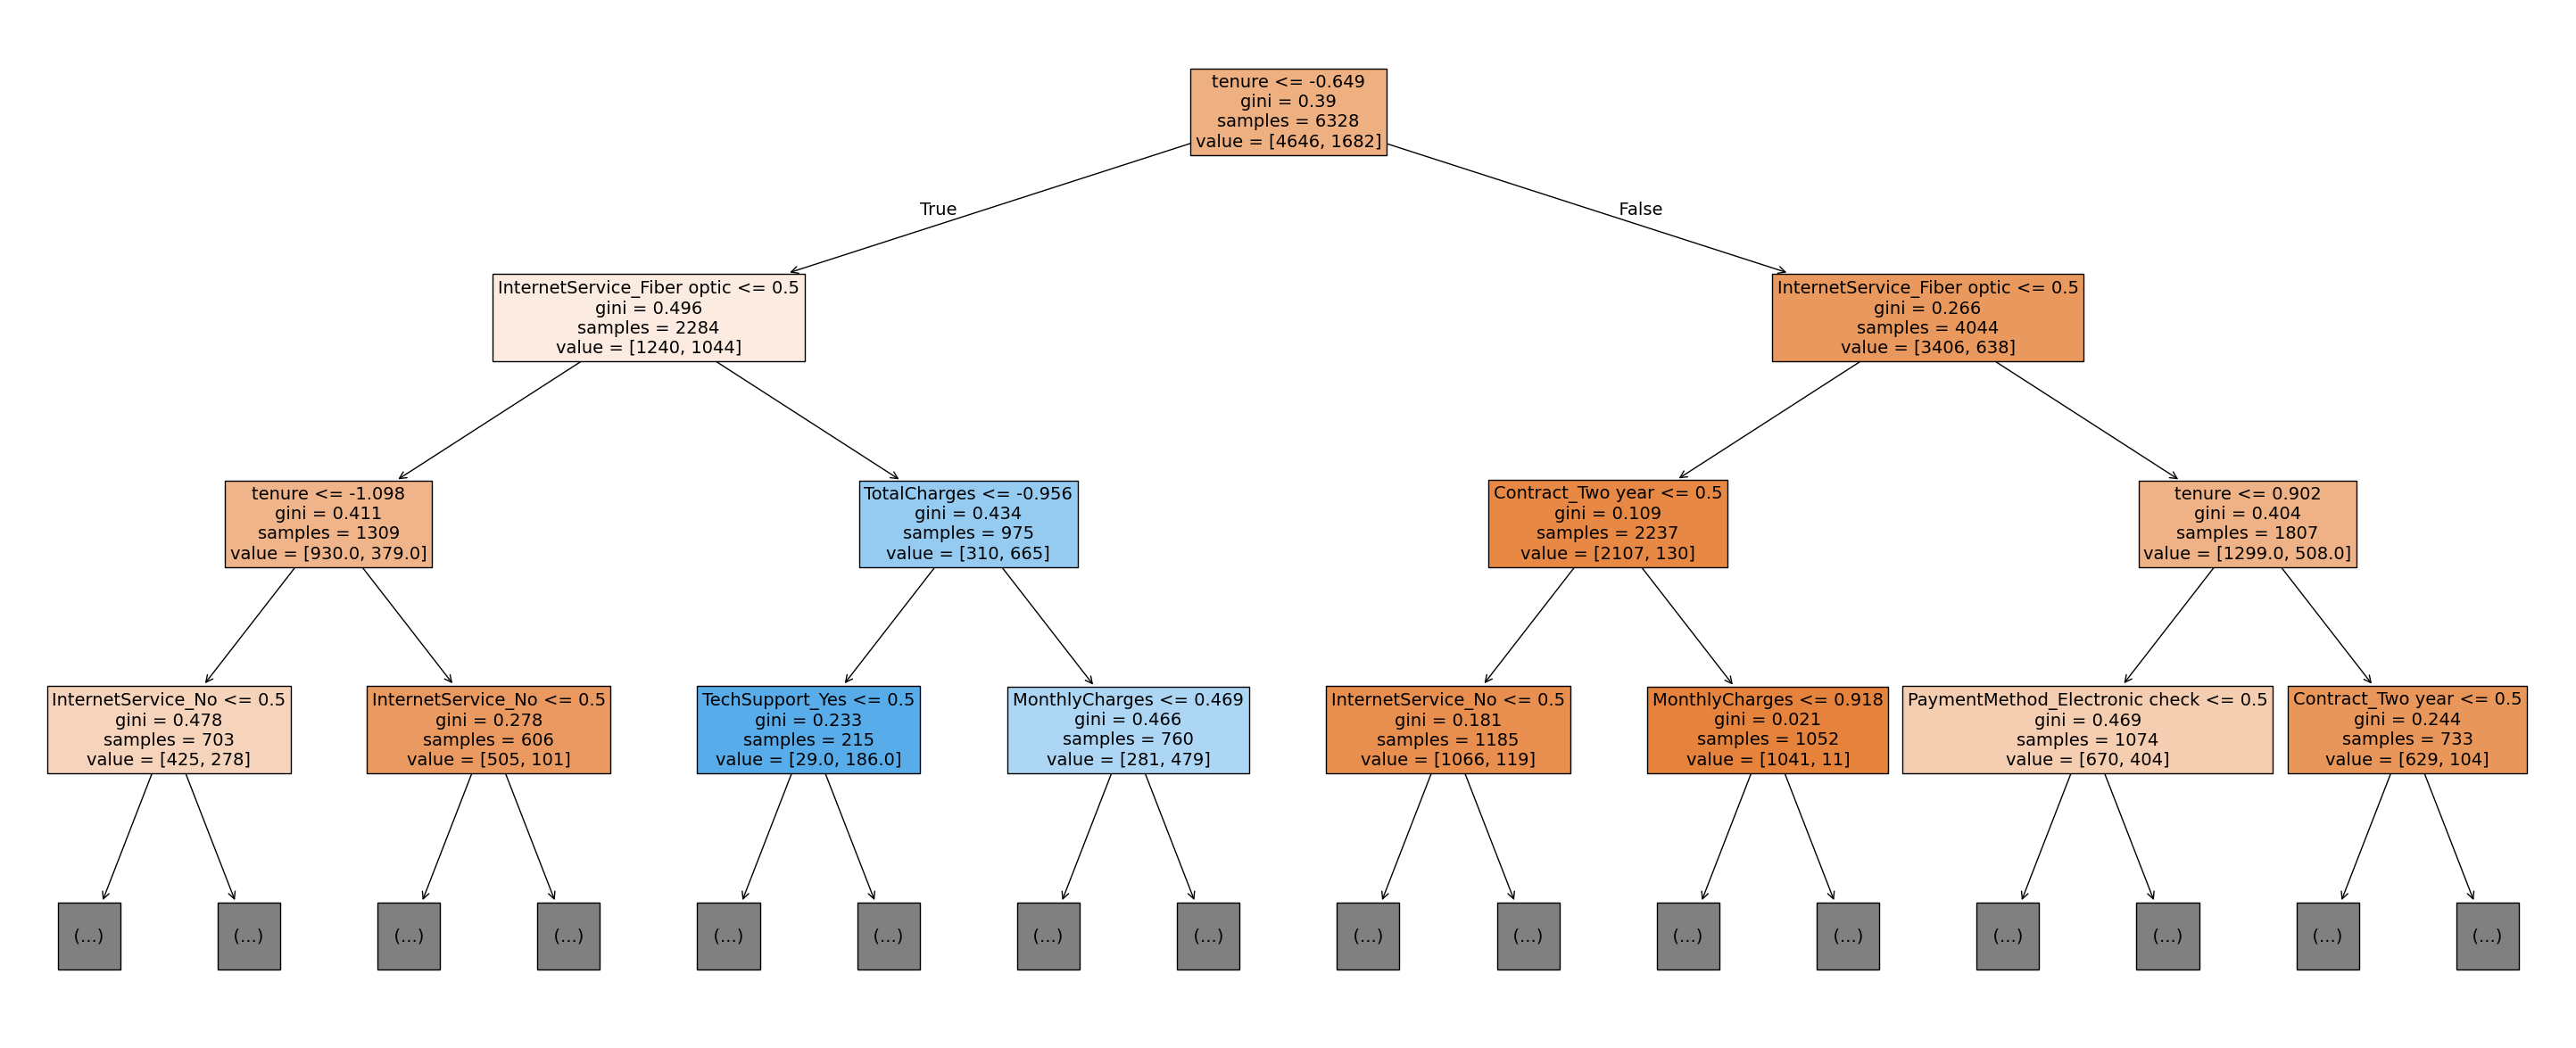

In [55]:
from sklearn import tree

clf = sklearn.tree.DecisionTreeClassifier(**results[7]['best_params'])
clf.fit(X_train_tr, y_train)

feature_names = ct.get_feature_names_out()
feature_names_clean = [name.split('__', 1)[-1] for name in feature_names]

fig = plt.figure(figsize=(37,15))
fig.tight_layout()
_ = tree.plot_tree(clf, feature_names=feature_names_clean, filled=True, fontsize=14, max_depth=3)
plt.savefig('./pictures/tree.png', dpi=300, bbox_inches='tight')

In [56]:
feature_names = ct.get_feature_names_out()
feature_names_clean = [name.split('__', 1)[-1] for name in feature_names]
feature_names_clean

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'MultipleLines_Yes',
 'DeviceProtection_Yes',
 'Dependents_Yes',
 'Contract_One year',
 'Contract_Two year',
 'Partner_Yes',
 'PaperlessBilling_Yes',
 'gender_Male',
 'StreamingTV_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'StreamingMovies_Yes',
 'OnlineBackup_Yes',
 'TechSupport_Yes',
 'OnlineSecurity_Yes',
 'PhoneService_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

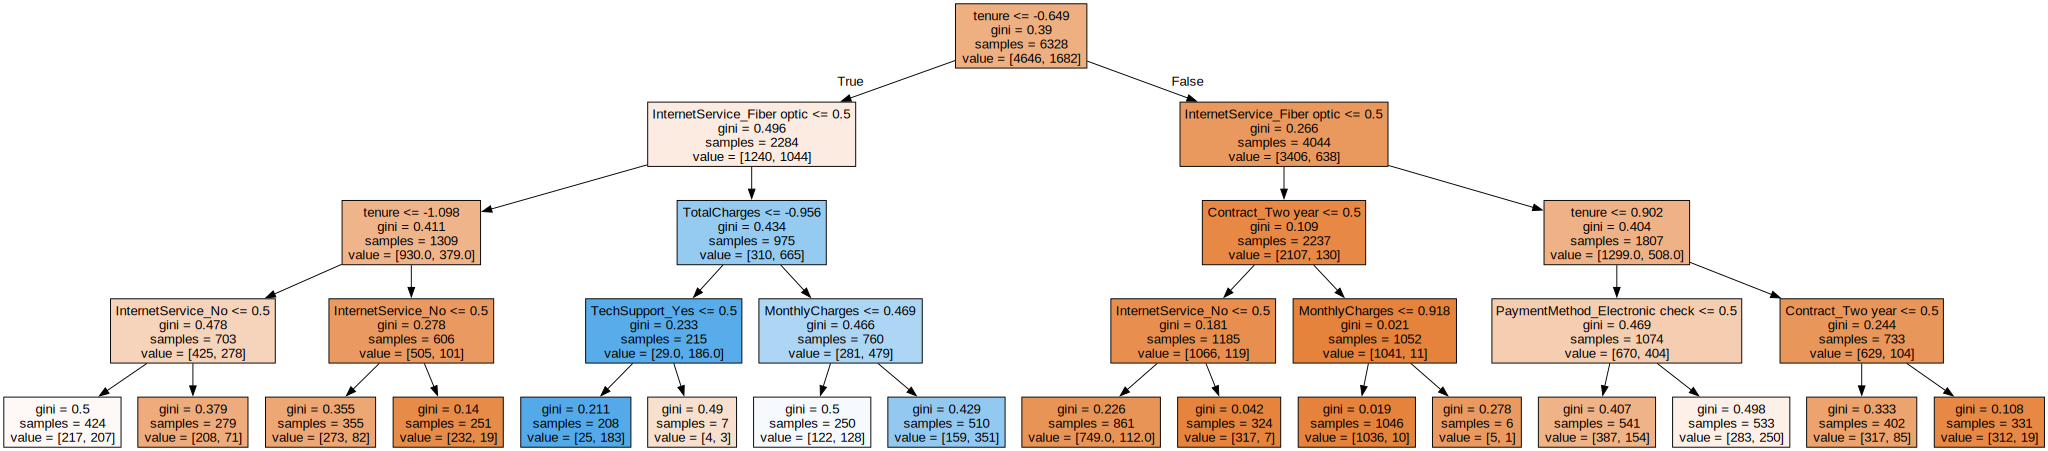

In [57]:
import graphviz

dot_data = tree.export_graphviz(clf, out_file=None,
                                feature_names=feature_names_clean,
                                filled=True)

graph = graphviz.Source(dot_data)
graph.render("./pictures/tree_visualization", format="png", cleanup=True)
graph